# R2：训练集、验证集与最佳模型

目标：在 PyTorch 中划分训练/验证数据，分别记录两条损失曲线，并保留验证损失最低时的模型参数。

## 训练损失与验证损失各回答什么问题

- 训练损失：模型对参与参数更新的数据拟合得怎样。
- 验证损失：模型对没有参与更新的数据泛化得怎样。

若训练损失持续下降，而验证损失开始上升，说明模型可能开始过拟合。最终应保留验证损失最低时的参数，而不是机械使用最后一个 epoch 的参数。

In [1]:
import copy

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)

In [2]:
# 模拟 200 条带噪声的线性数据，再随机划为训练集 160 条、验证集 40 条。
X_all = torch.linspace(-2, 2, 200).reshape(-1, 1)
y_all = 2 * X_all + 1 + 0.3 * torch.randn(200, 1)

indices = torch.randperm(len(X_all))
train_indices = indices[:160]
val_indices = indices[160:]

X_train, y_train = X_all[train_indices], y_all[train_indices]
X_val, y_val = X_all[val_indices], y_all[val_indices]

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
# 验证集不参与训练，不需要打乱；这里同样分批只是为了保持真实项目写法。
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=32, shuffle=False)

print('train samples:', len(X_train))
print('validation samples:', len(X_val))

train samples: 160
validation samples: 40


In [3]:
model = nn.Linear(1, 1)
loss_function = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)

def evaluate_loss(model, data_loader):
    # eval() 切换到评估模式；当前线性模型没有差异，但以后 Dropout/BatchNorm 会受影响。
    model.eval()
    total_loss = 0.0
    total_samples = 0

    # 验证不更新参数，也不需要保留计算图。
    with torch.no_grad():
        for batch_X, batch_y in data_loader:
            batch_prediction = model(batch_X)
            batch_loss = loss_function(batch_prediction, batch_y)
            total_loss += batch_loss.item() * len(batch_X)
            total_samples += len(batch_X)

    return total_loss / total_samples

In [4]:
epochs = 150
train_loss_history = []
val_loss_history = []
best_val_loss = float('inf')
best_epoch = 0
best_model_state = None

for epoch in range(epochs):
    # train() 切换到训练模式。
    model.train()

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        prediction = model(batch_X)
        loss = loss_function(prediction, batch_y)
        loss.backward()
        optimizer.step()

    # 每轮训练结束后，分别计算训练集和验证集的整体损失。
    train_loss = evaluate_loss(model, train_loader)
    val_loss = evaluate_loss(model, val_loader)
    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)

    # 只有验证损失变得更低时，才复制一份当前参数作为最佳模型。
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        best_model_state = copy.deepcopy(model.state_dict())

# 训练结束后，恢复验证损失最低时的参数。
model.load_state_dict(best_model_state)
print(f'best epoch: {best_epoch}')
print(f'best validation loss: {best_val_loss:.4f}')

best epoch: 147
best validation loss: 0.0920


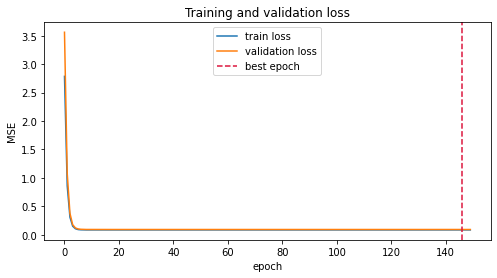

weight: 1.987
bias: 1.012


In [5]:
plt.figure(figsize=(8, 4))
plt.plot(train_loss_history, label='train loss')
plt.plot(val_loss_history, label='validation loss')
plt.axvline(best_epoch - 1, color='crimson', linestyle='--', label='best epoch')
plt.xlabel('epoch')
plt.ylabel('MSE')
plt.title('Training and validation loss')
plt.legend()
plt.show()

for name, parameter in model.named_parameters():
    print(f'{name}: {parameter.detach().item():.3f}')

## 本节结论

训练循环现在有了完整的泛化监控。今后面对神经网络时，核心判断不再只是“损失有没有下降”，而是“验证损失是否仍在改善”。下一节进入分类任务：使用 PyTorch 做二分类，并把 MSE 换为更合适的二元交叉熵损失。